In [115]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget
%pdb off

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import pyafn
from pyafn import rho, Cd
import random
from scipy.stats import lognorm
from scipy.stats import norm
from scipy.optimize import curve_fit
from emulationHelpers import readEmulationMI, plot_ventilation_model_fit, plot_empirical_model_error_distribution

#close all figures
plt.close('all')
plt.rcParams['figure.dpi'] = 140
im_scaling = .75
plt.rcParams['figure.figsize'] = [6.4 * im_scaling, 4.8 * im_scaling]
plt.rcParams['font.family'] = 'Times New Roman'

home_dir = "./"
display(home_dir)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Automatic pdb calling has been turned OFF


'./'

In [116]:
flowStatsMI, roomVentilationMI = readEmulationMI(home_dir=home_dir)

y_var = "flux-Norm"
x_var = "p-noInt_optp0-q_model-Norm"

Normalizing p cols: ['EP_p_avg', 'EP_p_avg-noInt', 'p-noInt_optp0-p0', 'p-noInt_optp0Cd-p0', 'pEP-noInt_optp0-p0', 'pEP-noInt_optp0Cd-p0', 'pEP_optp0-p0', 'pEP_optp0Cd-p0', 'p_avg-noInt', 'p_intensity-noInt', 'p_rms-noInt']
Normalizing u cols: ['EPR_mag', 'EPR_mag-noInt', 'EP_comp(u_avg,0)', 'EP_comp(u_avg,0)-noInt', 'EP_comp(u_avg,1)', 'EP_comp(u_avg,1)-noInt', 'EP_comp(u_avg,2)', 'EP_comp(u_avg,2)-noInt', 'EP_mag', 'EP_mag(u)_avg', 'EP_mag(u)_avg-noInt', 'EP_mag-noInt', 'EP_normal', 'EP_normal-noInt', 'EP_shear', 'EP_shear-noInt', 'EP_shear-noInt-qIn', 'EP_shear-noInt-qOut', 'EP_shear_o_qmodel', 'comp(u_avg,0)-noInt', 'comp(u_avg,1)-noInt', 'comp(u_avg,2)-noInt', 'flux', 'p-noInt_optp0-netq_model', 'p-noInt_optp0-q_model', 'p-noInt_optp0Cd-netq_model', 'p-noInt_optp0Cd-q_model', 'pEP-noInt_optp0-netq_model', 'pEP-noInt_optp0-q_model', 'pEP-noInt_optp0Cd-netq_model', 'pEP-noInt_optp0Cd-q_model', 'pEP_optp0-netq_model', 'pEP_optp0-q_model', 'pEP_optp0Cd-netq_model', 'pEP_optp0Cd-q_mode

/Users/nicholasbachand/Documents/Research/Cascade/city_block_cfd/emulationHelpers.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  roomVentilationMI["flux-Norm"] = roomVentilationMI["flux"] / roomVentilationMI["WS"]
/Users/nicholasbachand/Documents/Research/Cascade/city_block_cfd/emulationHelpers.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  roomVentilationMI["p-noInt_optp0-q_model-Norm"] = roomVentilationMI["p-noInt_optp0-q_model"] / roomVentilationMI["WS"]


Fitted parameters for Window, Flow Entering: popt=[1.15689785 0.10980474]
$C_d$ is 0.69, $\sigma$ is 0.11
NRMSE: 0.32, RMSE: 0.039
Bias: -0.0009, Error STD: 0.0391
Fitted parameters for Window, Flow Exiting: popt=[1.1230255  0.09762381]
$C_d$ is 0.67, $\sigma$ is 0.10
NRMSE: 0.36, RMSE: 0.050
Bias: 0.0007, Error STD: 0.0499


<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/z4/gbjchz2x4hs8f0k6b6t8m5jm0000gn/T/ipykernel_260/3479616124.py:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  model_name="$\sigma_{q_n}$ Bulk Fit PN",


For skylight=False, NRMSE: 0.2291, RMSE: 0.0431
Fitted parameters for Skylight, Flow Entering: popt=[9.72534673e-01 3.28484120e-16]
$C_d$ is 0.58, $\sigma$ is 0.00
NRMSE: 0.41, RMSE: 0.035
Bias: -0.0029, Error STD: 0.0344
Fitted parameters for Skylight, Flow Exiting: popt=[1.21368832 0.12637218]
$C_d$ is 0.73, $\sigma$ is 0.13
NRMSE: 0.36, RMSE: 0.043
Bias: -0.0011, Error STD: 0.0431
For skylight=True, NRMSE: 0.2711, RMSE: 0.0414


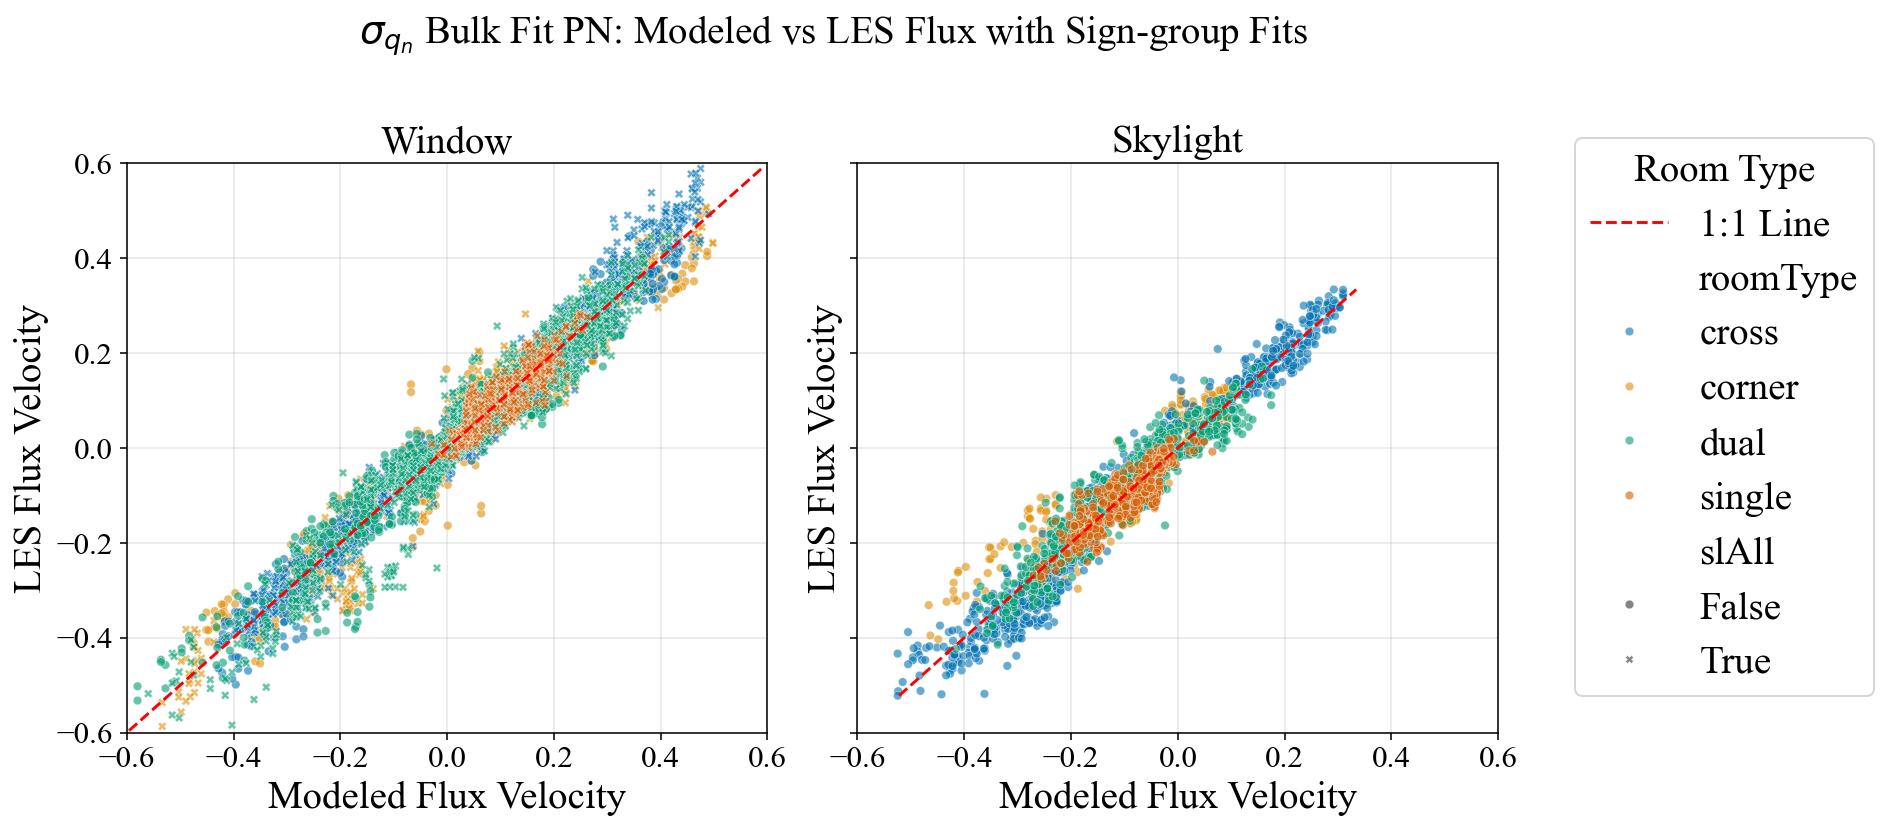

In [117]:
# Row 1: baseline q model (categorical hue)
fig, ax, xAdjusted, fittedParams = plot_ventilation_model_fit(
    data=flowStatsMI,
    y_var=y_var,
    x_var=x_var,
    x_var2=None,
    hue="roomType",
    style="slAll",
    model_func=pyafn.ventilationReDecomp_q,
    model_name="$\sigma_{q_n}$ Bulk Fit PN",
    p0=[1.0, 0.1],
    bounds=([0.1, 0], [np.inf, np.inf]),
    adjustData=True,
    show_assymptotes=True,
    add_numeric_colorbar=False,
    return_data=True,
    return_params=True
)

flowStatsMI["q_model-Norm-Adjusted"] = xAdjusted

Total count: 8512
  Window: 5824
  Skylight: 2688


,opening_type,mu_hat,sigma_hat,n
0,Window,-0.004366,0.050195,5824
1,Skylight,0.008873,0.049406,2688


Total count: 8512
  Window: 5824
  Skylight: 2688


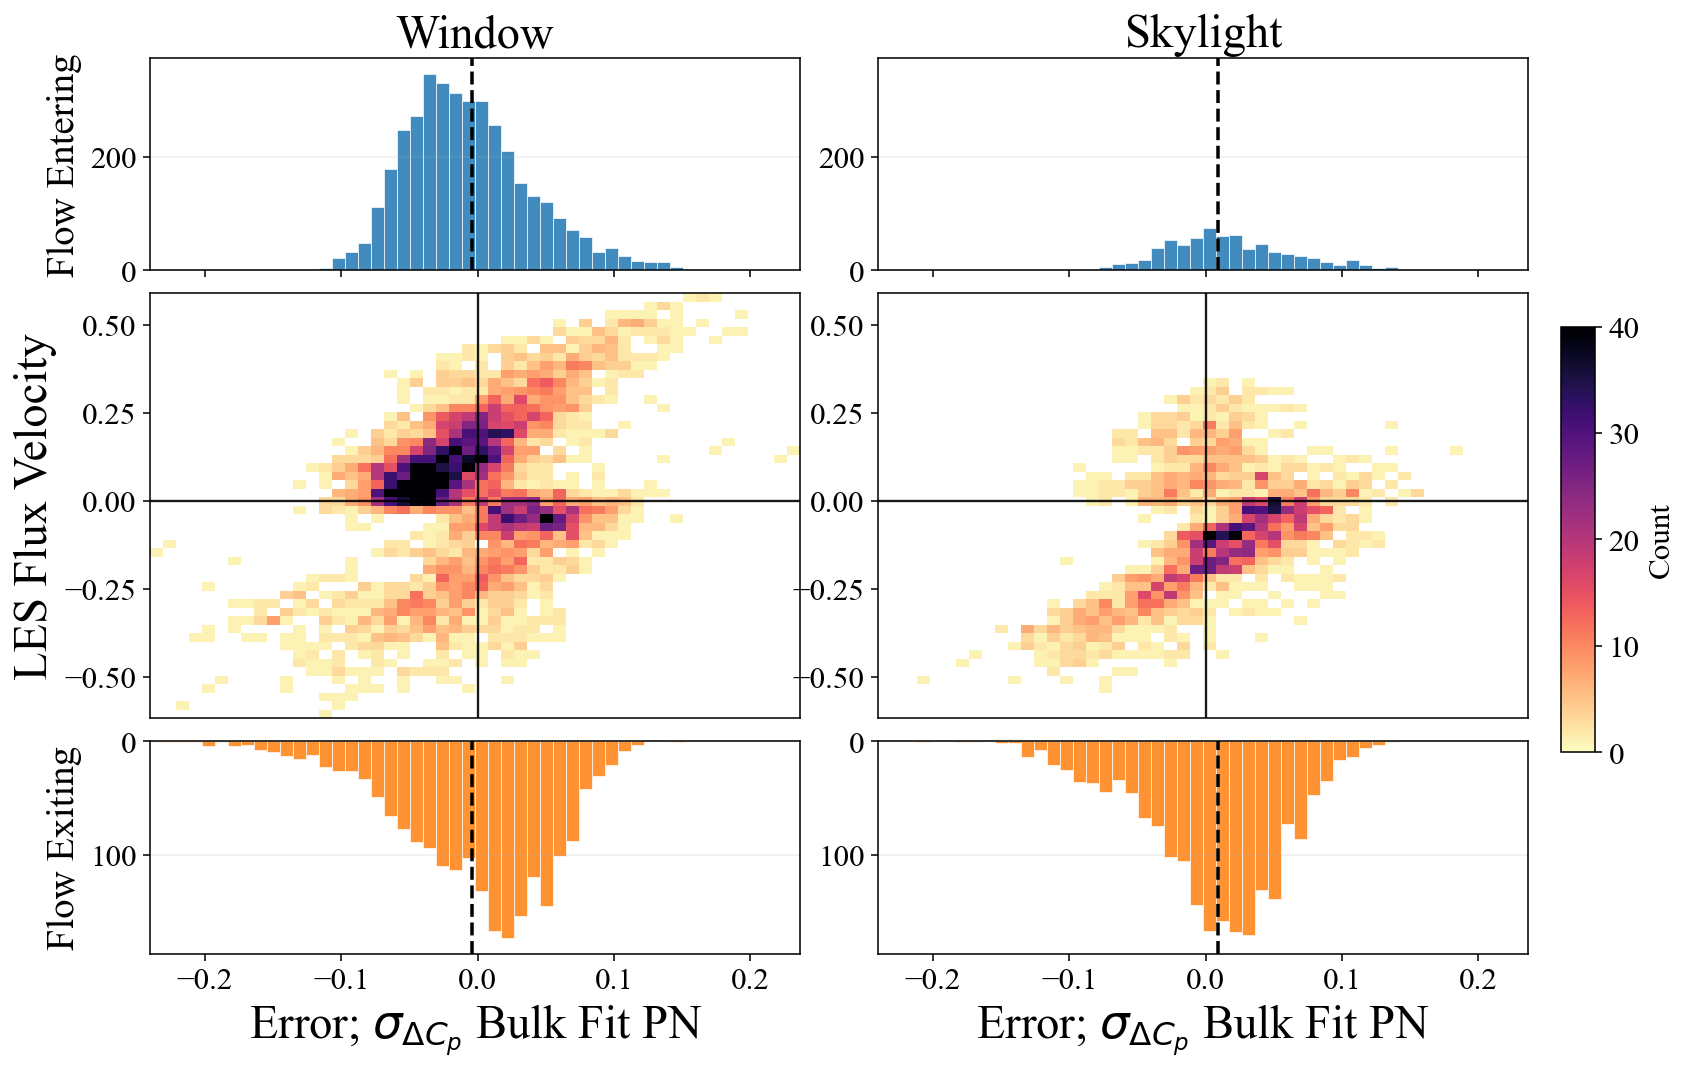

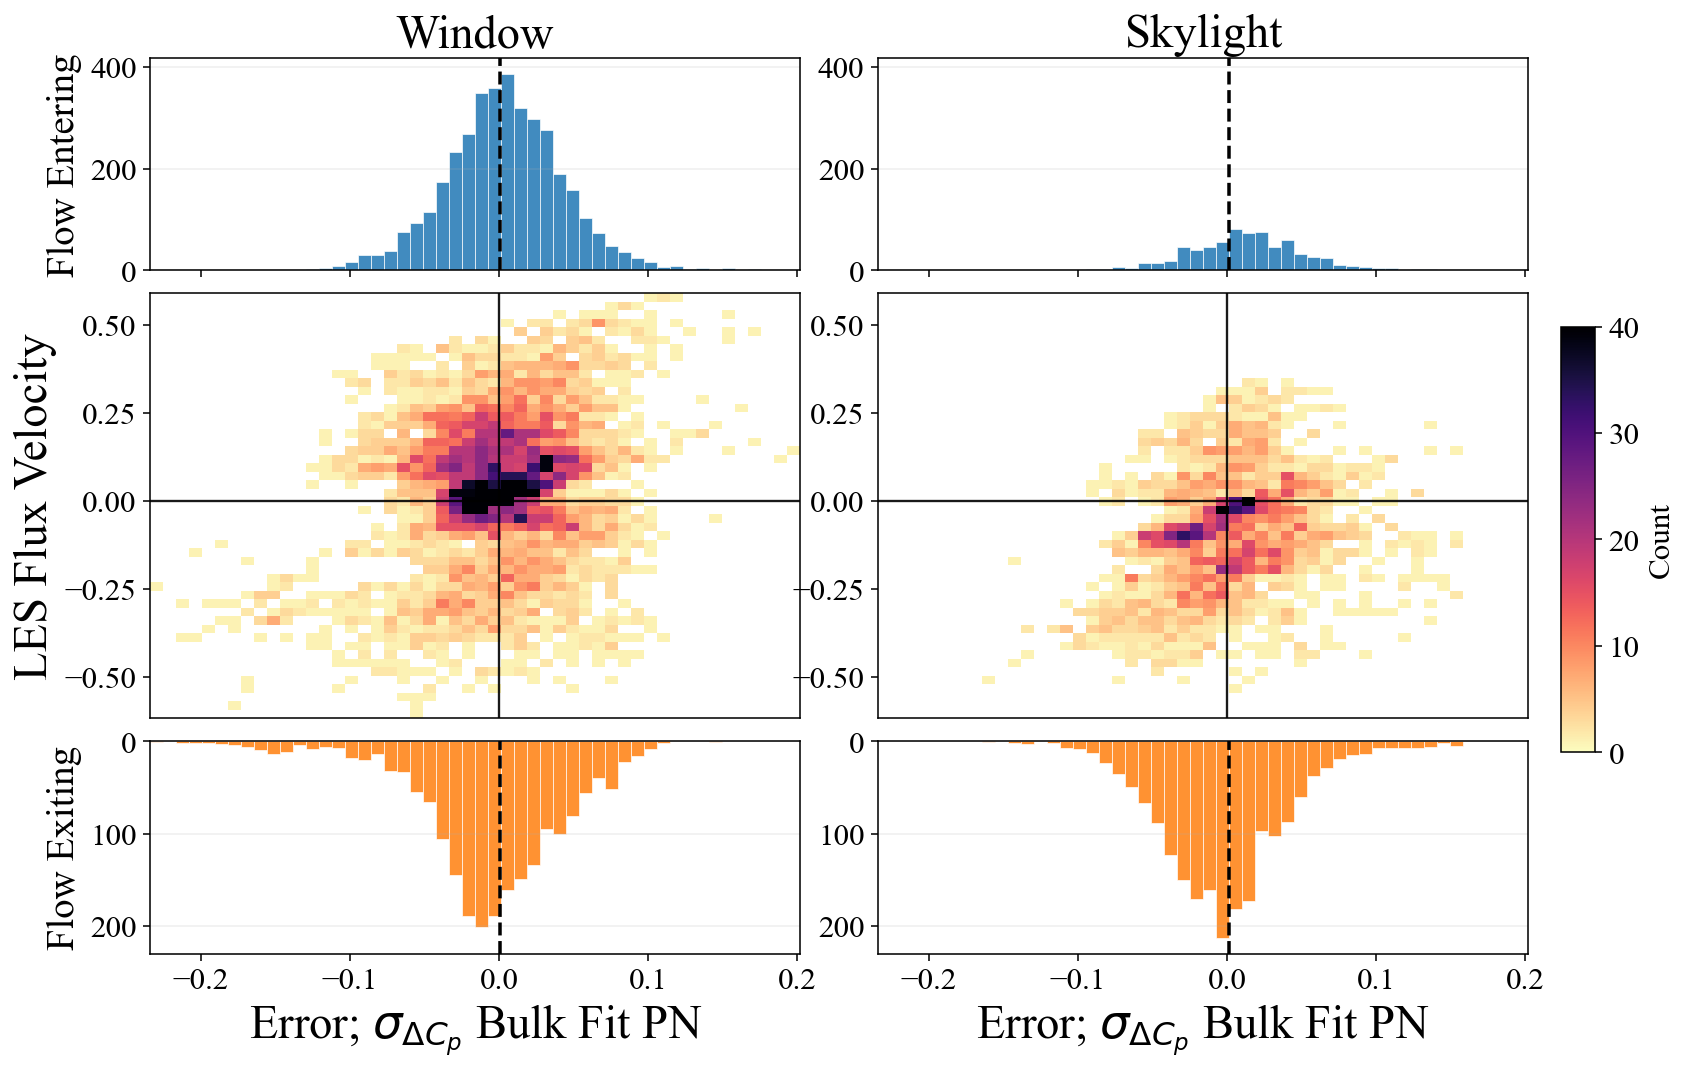

In [118]:
fig, axs, error_stats = plot_empirical_model_error_distribution(
    flowStatsMI,
    y_var=y_var,
    x_var=x_var,
    plot_mode="hist2d",
    split_by_subgroup=True,
    show_split_marginals=True,
    bins=50,
    title="Empirical Error vs Observed Ventilation by Opening Type",
    cmap="magma_r",
    error_xlabel=r"Error; $\sigma_{\Delta C_p}$ Bulk Fit PN",
    ventilation_ylabel="LES Flux Velocity",
    positive_ylabel="Flow Entering",
    negative_ylabel="Flow Exiting",
    print_counts=True,
    colorbar_max=40,
)
display(
    pd.DataFrame(
        [
            {
                "opening_type": opening_type,
                "mu_hat": np.nan if stats is None else stats["mu_hat"],
                "sigma_hat": np.nan if stats is None else stats["sigma_hat"],
                "n": 0 if stats is None else stats["n"],
            }
            for opening_type, stats in error_stats.items()
        ]
    )
)

fig, axs, error_stats = plot_empirical_model_error_distribution(
    flowStatsMI,
    y_var=y_var,
    x_var="q_model-Norm-Adjusted",
    plot_mode="hist2d",
    split_by_subgroup=True,
    show_split_marginals=True,
    bins=50,
    title="Empirical Error vs Observed Ventilation by Opening Type",
    cmap="magma_r",
    error_xlabel=r"Error; $\sigma_{\Delta C_p}$ Bulk Fit PN",
    ventilation_ylabel="LES Flux Velocity",
    positive_ylabel="Flow Entering",
    negative_ylabel="Flow Exiting",
    print_counts=True,
    colorbar_max=40
)


In [119]:
from pathlib import Path

from emulationHelpers import (
    fit_bayesian_ventilation_q_subgroups,
    fit_bayesian_ventilation_p_subgroups,
    load_bayesian_q_ventilation_fit_results,
    load_bayesian_ventilation_fit_results,
    plot_bayesian_ventilation_q_fit_results,
    plot_bayesian_ventilation_p_fit_results,
    plot_bayesian_ventilation_parameter_posteriors,
    save_bayesian_ventilation_fit_results,
    summarize_bayesian_ventilation_fits,
)

a_mu = 1.0
a_sigma = 0.1
p_rms_var = "p_rms-noInt-Norm"
obs_sigma = 0.01

sample_kwargs = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "cores": 4,
    "progressbar": True,
}

cache_dir = Path("mcmc_cache") / "pressure_scalar_posteriors_log_p_rms"
rerun_mcmc = True

if cache_dir.exists() and not rerun_mcmc:
    bayes_fits = load_bayesian_ventilation_fit_results(cache_dir)
    print(f"Loaded cached Bayesian fits from {cache_dir}")
else:
    bayes_fits = fit_bayesian_ventilation_p_subgroups(
        data=flowStatsMI,
        y_var=y_var,
        x_var=x_var,
        p_rms_var=p_rms_var,
        a_mu=a_mu,
        a_sigma=a_sigma,
        obs_sigma=obs_sigma,
        sample_kwargs=sample_kwargs,
        random_seed=42,
    )
    save_bayesian_ventilation_fit_results(bayes_fits, cache_dir)
    print(f"Saved Bayesian fits to {cache_dir}")


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Slice: [a]
>Slice: [p_rms]
>Slice: [sigma_obs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Bayesian fit Window, Flow Entering: a=1.1130, p_rms=0.0486, sigma_obs=0.0390


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Slice: [a]
>Slice: [p_rms]
>Slice: [sigma_obs]


...

/Users/nicholasbachand/codes/pyAFN/pyafn/ventilation.py:101: RuntimeWarning: overflow encountered in divide
  I[mask] = p_rms / (2 * np.abs(delP[mask]))
/Users/nicholasbachand/codes/pyAFN/pyafn/ventilation.py:83: RuntimeWarning: overflow encountered in multiply
  H_bound = np.sqrt(2 * I)


/Users/nicholasbachand/codes/pyAFN/pyafn/ventilation.py:101: RuntimeWarning: overflow encountered in divide
  I[mask] = p_rms / (2 * np.abs(delP[mask]))


/Users/nicholasbachand/codes/pyAFN/pyafn/ventilation.py:83: RuntimeWarning: overflow encountered in multiply
  H_bound = np.sqrt(2 * I)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


Bayesian fit Skylight, Flow Exiting: a=1.1572, p_rms=0.0560, sigma_obs=0.0414
Saved Bayesian fits to mcmc_cache/pressure_scalar_posteriors_alpha_lognormal


,n_obs,panel,direction,parameter,mean,sd,hdi_3%,median,hdi_97%
0,3812,Window,Flow Entering,a,1.112936,0.005206,1.102952,1.113041,1.122649
1,3812,Window,Flow Entering,p_rms,0.048639,0.001458,0.045832,0.048618,0.051330
2,3812,Window,Flow Entering,sigma_obs,0.039026,0.000433,0.038225,0.039022,0.039850
3,2012,Window,Flow Exiting,a,1.089281,0.006409,1.077501,1.089209,1.101329
4,2012,Window,Flow Exiting,p_rms,0.042923,0.001817,0.039433,0.042875,0.046459
5,2012,Window,Flow Exiting,sigma_obs,0.048595,0.000793,0.047130,0.048577,0.050138
6,572,Skylight,Flow Entering,a,0.972466,0.009441,0.954542,0.972535,0.989616
7,572,Skylight,Flow Entering,p_rms,0.000073,0.000096,0.000003,0.000041,0.000340
8,572,Skylight,Flow Entering,sigma_obs,0.033929,0.000973,0.032155,0.033909,0.035781
9,2116,Skylight,Flow Exiting,a,1.157109,0.007824,1.142502,1.157173,1.172001


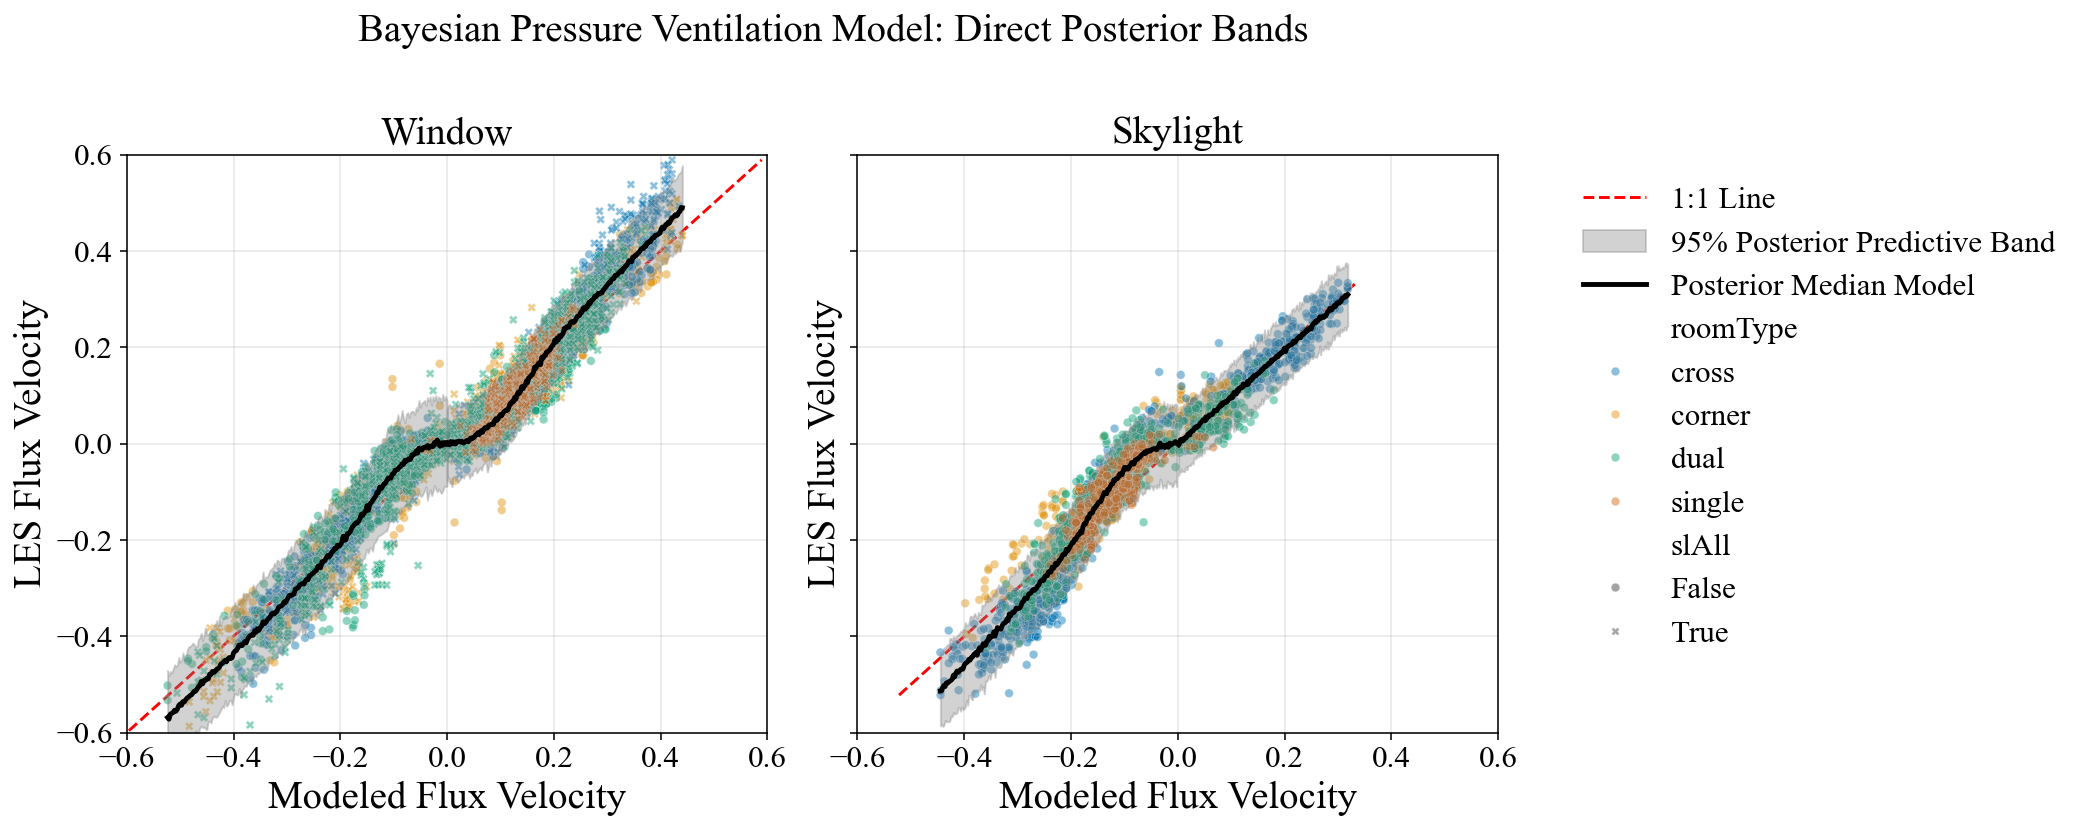

In [120]:
fig, axs = plot_bayesian_ventilation_p_fit_results(
    data=flowStatsMI,
    fit_results=bayes_fits,
    y_var=y_var,
    x_var=x_var,
    hue="roomType",
    style="slAll",
    model_name="Bayesian Pressure Ventilation Model",
    credible_interval=0.95,
    posterior_draws_for_curves=400,
    show_scatter=True,
    scatter_alpha=0.45,
    band_alpha=0.35,
)

bayes_summary = summarize_bayesian_ventilation_fits(bayes_fits)
display(bayes_summary)
plt.show()


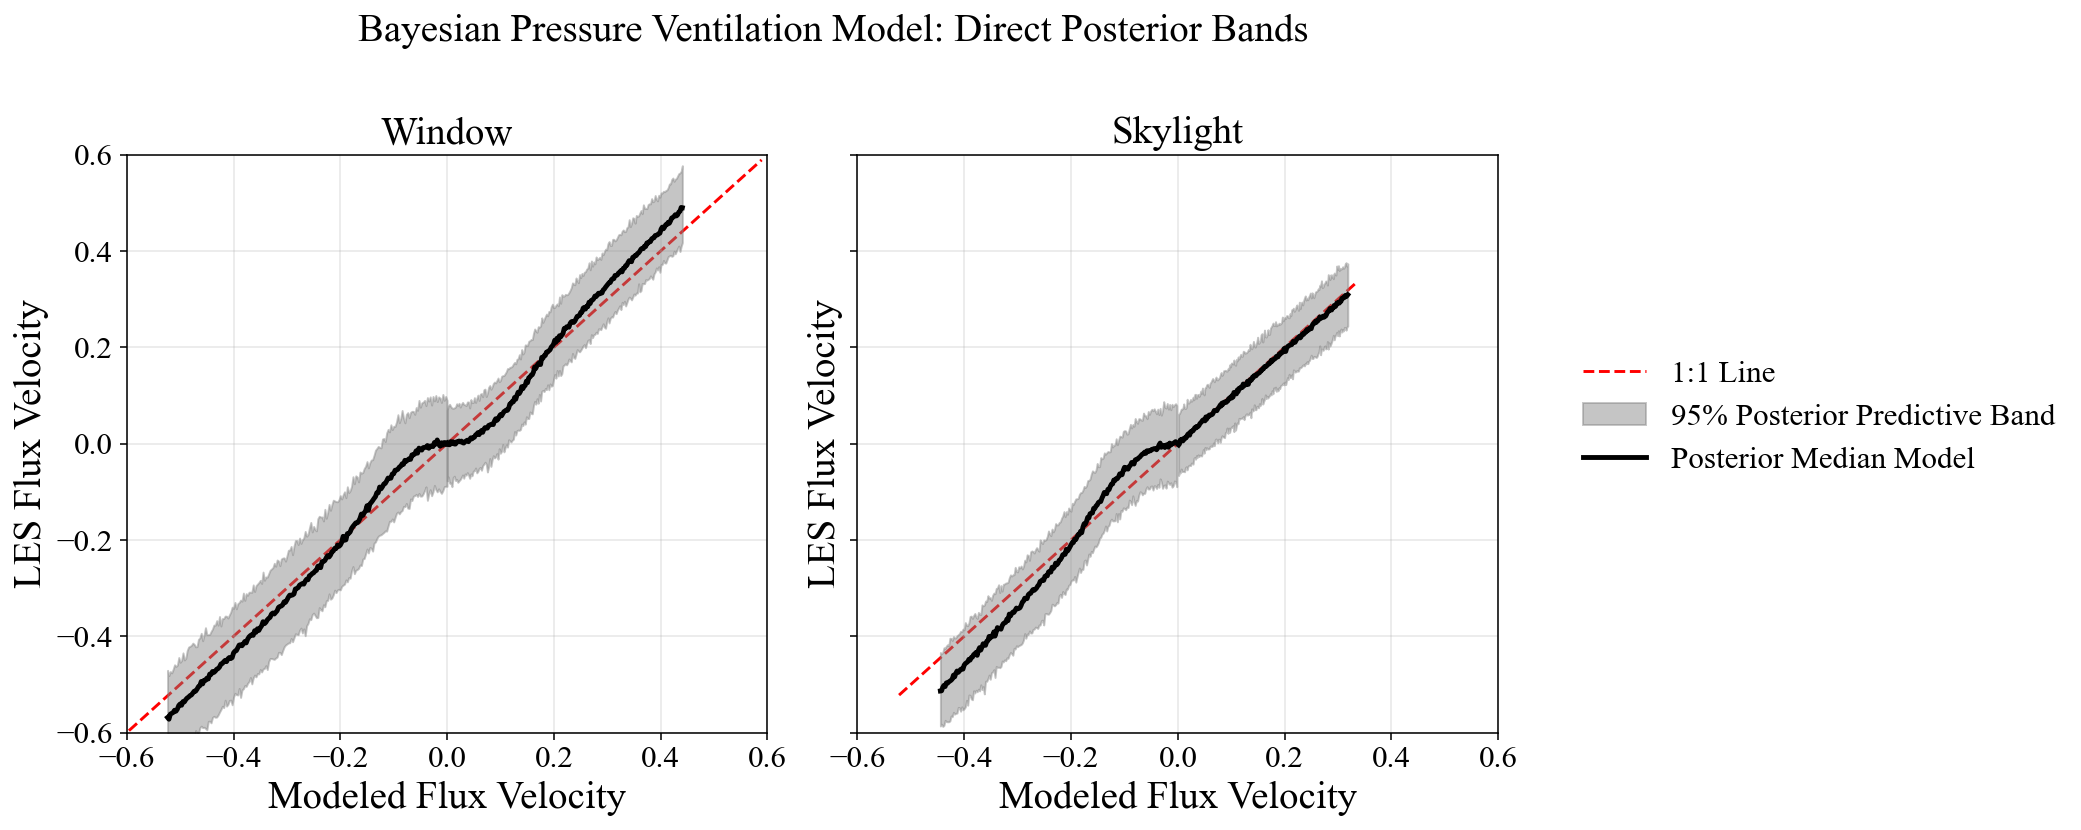

In [121]:
fig, axs = plot_bayesian_ventilation_p_fit_results(
    data=flowStatsMI,
    fit_results=bayes_fits,
    y_var=y_var,
    x_var=x_var,
    hue="roomType",
    style="slAll",
    credible_interval=0.95,
    posterior_draws_for_curves=400,
    show_scatter=False,
    band_alpha=0.45,
)
plt.show()


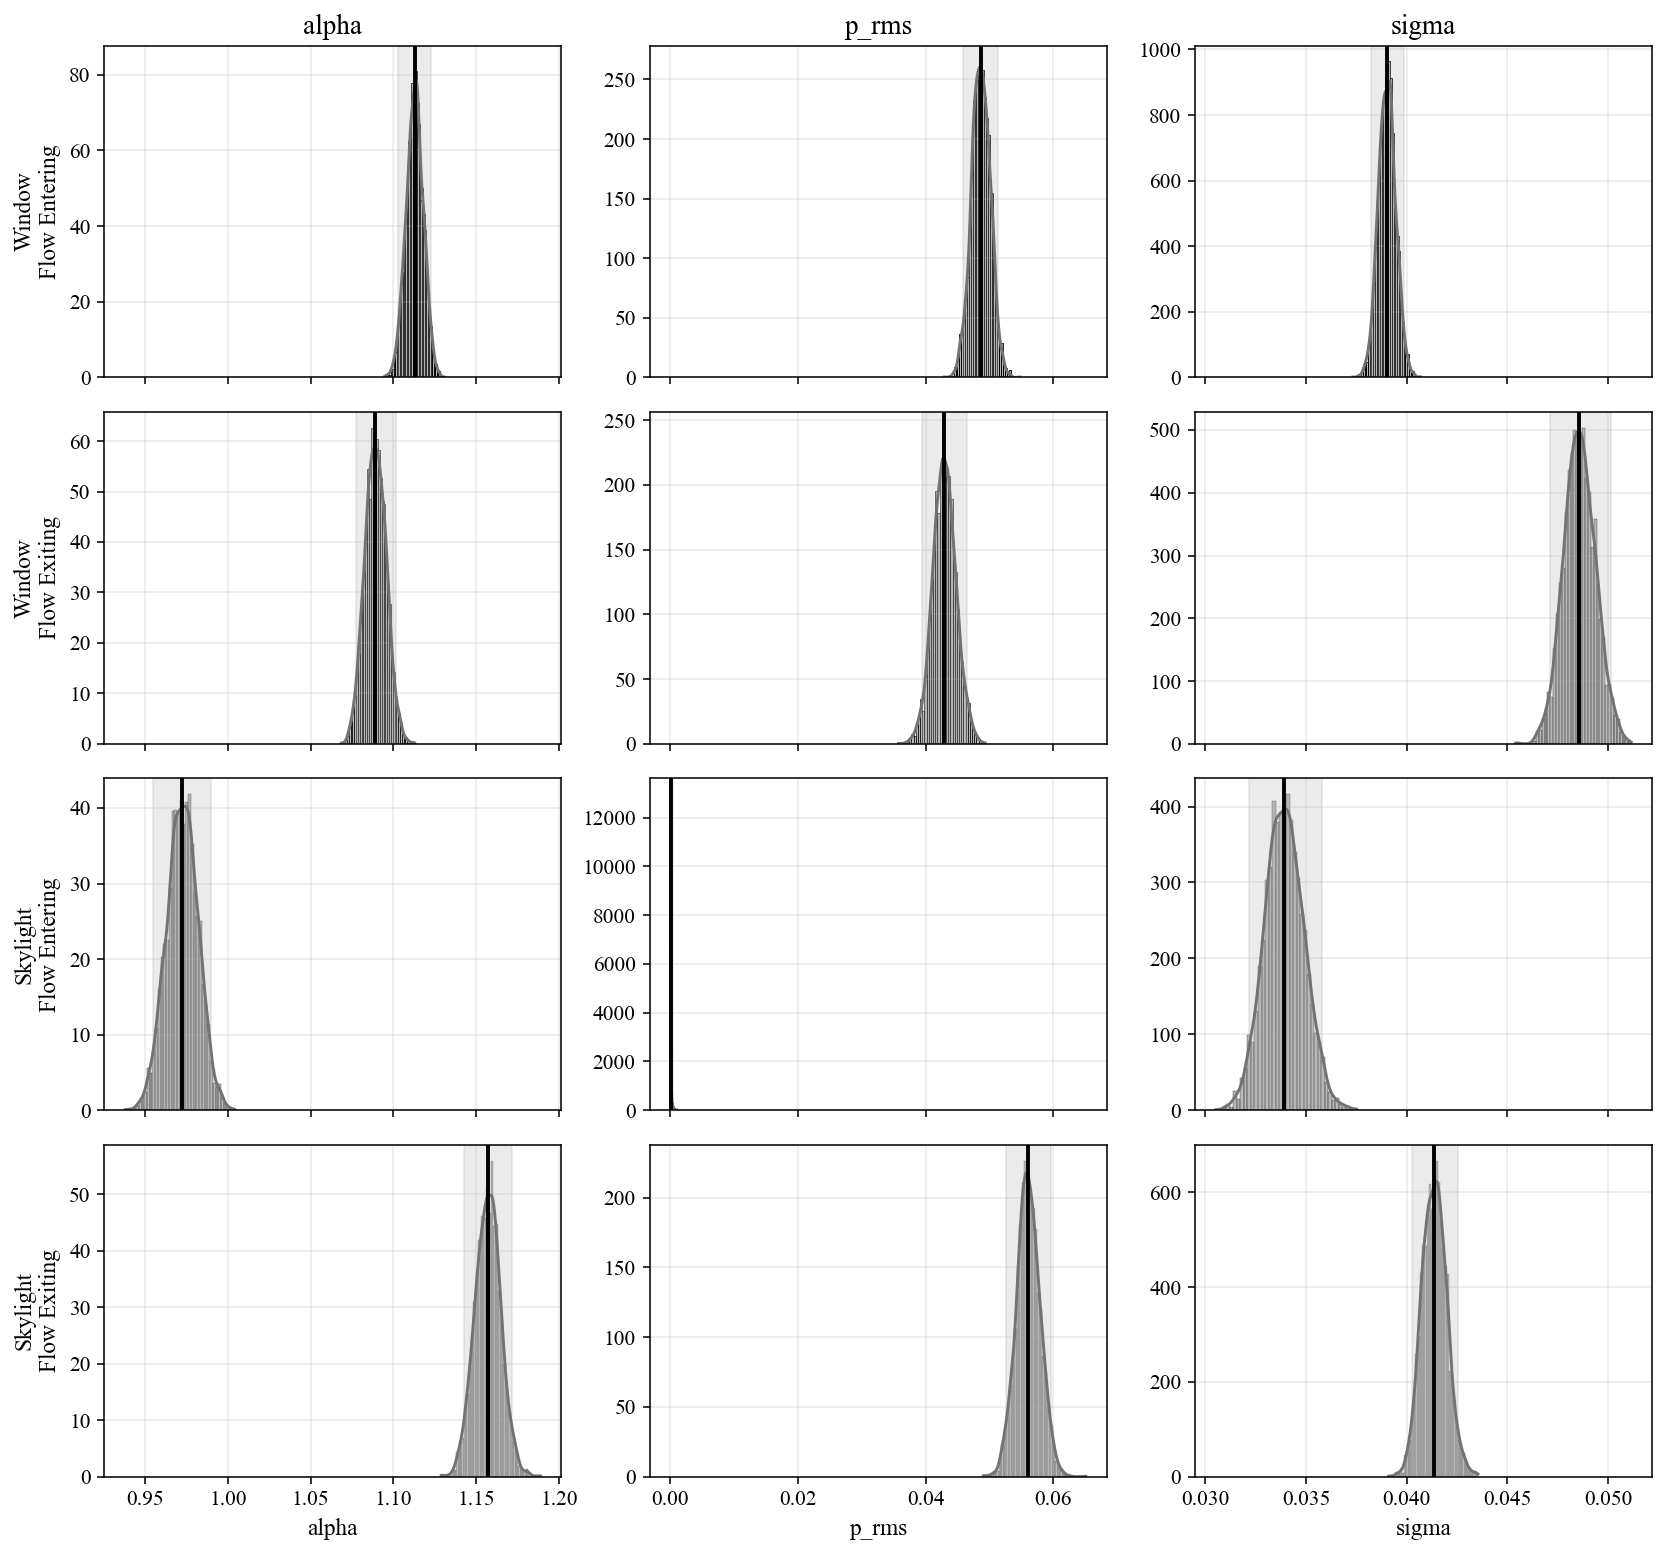

In [122]:
fig, axs = plot_bayesian_ventilation_parameter_posteriors(
    bayes_fits,
    columns=["a", "p_rms", "sigma_obs"],
    kde=False,
    overlay_normal=True,
    normal_line_color="tab:blue",
)
plt.show()


In [ ]:
# Bayesian q_rms workflow for $\\sigma_{q_n}$ Bulk Measured PN
q_rms_var = "rms-mass_flux-Norm"

q_cache_dir = Path("mcmc_cache") / "q_rms_scalar_posteriors_log_q_rms"
rerun_q_mcmc = True

if q_cache_dir.exists() and not rerun_q_mcmc:
    q_bayes_fits = load_bayesian_q_ventilation_fit_results(q_cache_dir)
    print(f"Loaded cached Bayesian q fits from {q_cache_dir}")
else:
    q_bayes_fits = fit_bayesian_ventilation_q_subgroups(
        data=flowStatsMI,
        y_var=y_var,
        x_var=x_var,
        q_rms_var=q_rms_var,
        a_mu=a_mu,
        a_sigma=a_sigma,
        obs_sigma=obs_sigma,
        sample_kwargs=sample_kwargs,
        random_seed=42,
    )
    save_bayesian_ventilation_fit_results(q_bayes_fits, q_cache_dir)
    print(f"Saved Bayesian q fits to {q_cache_dir}")


In [ ]:
fig, axs = plot_bayesian_ventilation_q_fit_results(
    data=flowStatsMI,
    fit_results=q_bayes_fits,
    y_var=y_var,
    x_var=x_var,
    hue="roomType",
    style="slAll",
    model_name="Bayesian q_rms Ventilation Model",
    credible_interval=0.95,
    posterior_draws_for_curves=400,
    show_scatter=True,
    scatter_alpha=0.45,
    band_alpha=0.35,
)

q_bayes_summary = summarize_bayesian_ventilation_fits(q_bayes_fits)
display(q_bayes_summary)
plt.show()


In [ ]:
fig, axs = plot_bayesian_ventilation_q_fit_results(
    data=flowStatsMI,
    fit_results=q_bayes_fits,
    y_var=y_var,
    x_var=x_var,
    hue="roomType",
    style="slAll",
    credible_interval=0.95,
    posterior_draws_for_curves=400,
    show_scatter=False,
    band_alpha=0.45,
)
plt.show()


In [ ]:
fig, axs = plot_bayesian_ventilation_parameter_posteriors(
    q_bayes_fits,
    columns=["a", "q_rms", "sigma_obs"],
    kde=False,
    overlay_normal=True,
    normal_line_color="tab:blue",
)
plt.show()
